**Import data, cleaning and consistency verify**

---


In [4]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# import csv file
data = pd.read_csv('Walmart.csv')
data.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [5]:
# re-arrange date column
def data_arrange(x):
  x = str(x)
  year = x[6:10]
  month = x[3:5]
  day = x[0:2]
  return year + '-' + month + '-' + day
data['Date'] = data['Date'].apply(data_arrange)
data['Date'] = pd.to_datetime(data['Date'])
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 402.3 KB


In [6]:
# null data check
data.isnull().sum()

,0
Store,0
Date,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0


In [7]:
# crete $M column for better representation
data['Weekly Sales $M'] = data['Weekly_Sales'] / 1000000
data['Weekly Sales $M'] = data['Weekly Sales $M'].round(2)
data.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Weekly Sales $M
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,1.64
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,1.64
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,1.61
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,1.41
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,1.55


**Exploratory Data Analysis**

---

In [8]:
data.describe()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Weekly Sales $M
count,6435.000000,6435,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,2011-06-17 00:00:00,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151,1.046973
min,1.000000,2010-02-05 00:00:00,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000,0.210000
25%,12.000000,2010-10-08 00:00:00,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000,0.550000
50%,23.000000,2011-06-17 00:00:00,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000,0.960000
75%,34.000000,2012-02-24 00:00:00,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000,1.420000
max,45.000000,2012-10-26 00:00:00,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000,3.820000
std,12.988182,NaN,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885,0.564373


Text(0.5, 1.0, 'Weekly sales distribution')

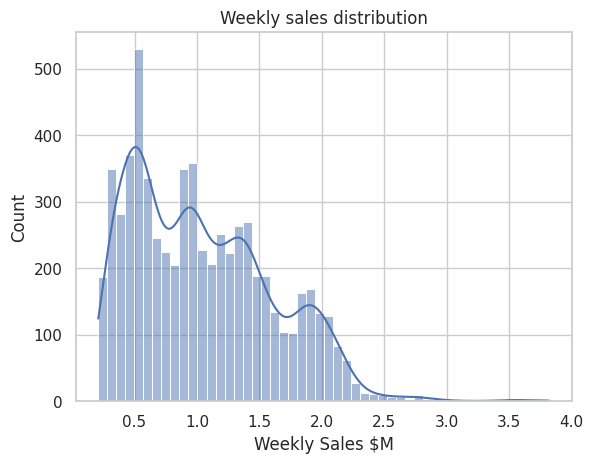

In [9]:
# EDA for weekly sales
sns.set_theme(style="whitegrid")
ax = sns.histplot(data, x = 'Weekly Sales $M', bins = 50, kde = True)
plt.title('Weekly sales distribution')


Text(0.5, 1.0, 'Temperature distribution')

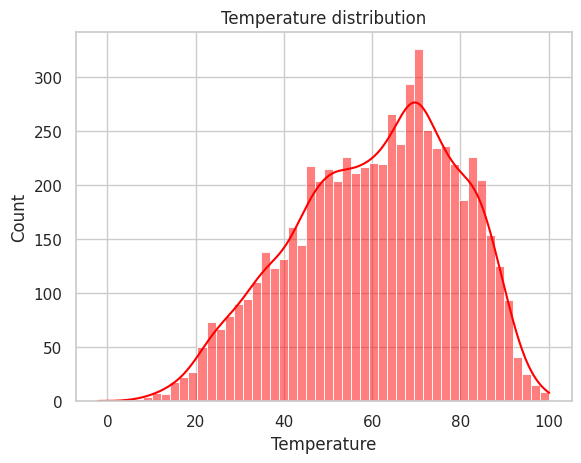

In [10]:
# EDA for temperature
ax = sns.histplot(data, x = 'Temperature', bins = 50, kde = True, color = 'red')
plt.title('Temperature distribution')

Text(0.5, 1.0, 'Fuel price distribution')

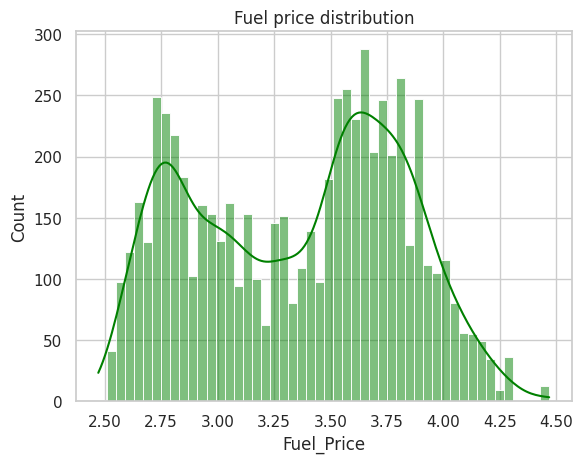

In [11]:
# EDA for fuel price
ax = sns.histplot(data, x = 'Fuel_Price', bins = 50, kde = True, color = 'green')
plt.title('Fuel price distribution')

Text(0.5, 1.0, 'Unemployment rate distribution')

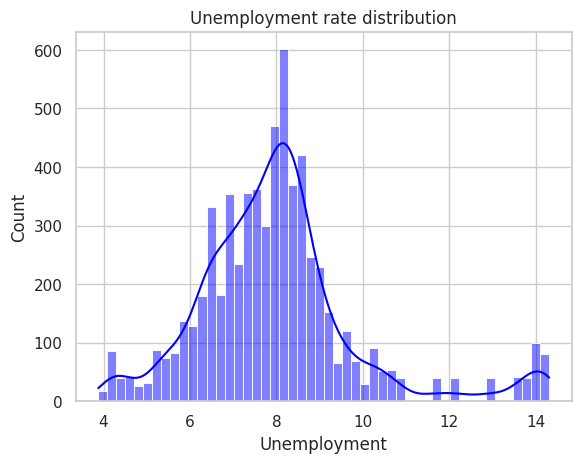

In [12]:
# EDA for unemplyment
ax = sns.histplot(data, x = 'Unemployment', bins = 50, kde = True, color = 'blue')
plt.title('Unemployment rate distribution')

Text(0.5, 1.0, 'Customer price index distribution')

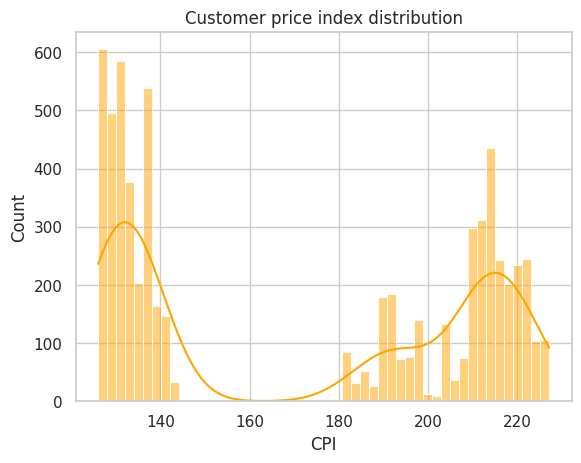

In [13]:
# EDA for CPI
ax = sns.histplot(data, x = 'CPI', bins = 50, kde = True, color = 'orange')
plt.title('Customer price index distribution')

Text(0.5, 1.0, 'Top 10 stores for revenue')

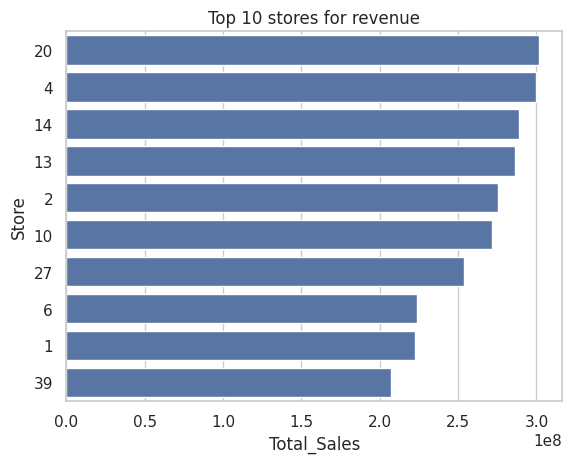

In [14]:
# top 10 stores for overall revenue
data_gr_stores = data.groupby('Store').agg(
    Total_Sales = ('Weekly_Sales', 'sum'),
    AVG_Temperature = ('Temperature', 'mean'),
    AVG_Fuel_Price = ('Fuel_Price', 'mean'),
).reset_index()
data_gr_stores = data_gr_stores.sort_values(by = 'Total_Sales', ascending = False).head(10)
data_gr_stores['Store'] = data_gr_stores['Store'].astype('str')
sns.barplot(data_gr_stores, y ='Store', x = 'Total_Sales')
plt.title('Top 10 stores for revenue')

**Seasonality**

---

In [15]:
# group data for all stores weekly
data_weekly = data.groupby('Date').agg(
    Weekly_Sales = ('Weekly_Sales', 'sum'),
    AVG_Temperature = ('Temperature', 'mean'),
    AVG_Fuel_Price = ('Fuel_Price', 'mean'),
    AVG_CPI = ('CPI', 'mean'),
    AVG_Unemployment = ('Unemployment', 'mean'),
    Holiday_flag = ('Holiday_Flag', 'mean')
)
data_weekly.head()

,Weekly_Sales,AVG_Temperature,AVG_Fuel_Price,AVG_CPI,AVG_Unemployment,Holiday_flag
Date,,,,,,
2010-02-05,49750740.50,34.037333,2.717844,167.730885,8.619311,0.0
2010-02-12,48336677.63,34.151333,2.694022,167.825608,8.619311,1.0
2010-02-19,48276993.78,37.719778,2.672067,167.871686,8.619311,0.0
2010-02-26,43968571.13,39.243556,2.683933,167.909657,8.619311,0.0
2010-03-05,46871470.30,42.917333,2.731200,167.947628,8.619311,0.0


<Axes: xlabel='Date', ylabel='Weekly_Sales'>

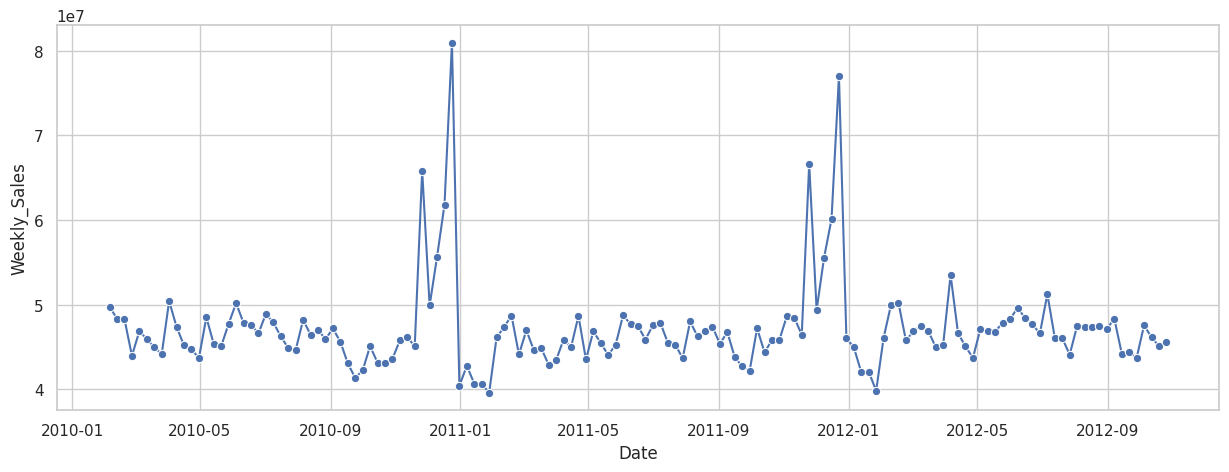

In [16]:
# create a timeline for all stores' revenue
plt.figure(figsize = (15, 5))
sns.lineplot(x='Date', y='Weekly_Sales', data=data_weekly, marker = 'o')
# two major at the end of each year have been found

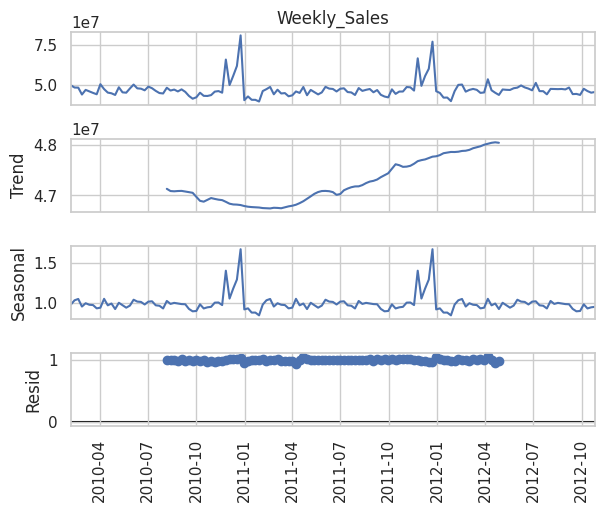

In [17]:
# check the seasonality with 52 weeks AKA annually
from statsmodels.tsa.seasonal import seasonal_decompose
seasonal_decompose(data_weekly['Weekly_Sales'], model = 'multiplicative', period = 52).plot()
plt.xticks(rotation = 90)
plt.show()
# two important spikes that cause a x1.7 multiplier are present at the end of the year
# the trend cleaned from seasonality is incrementing

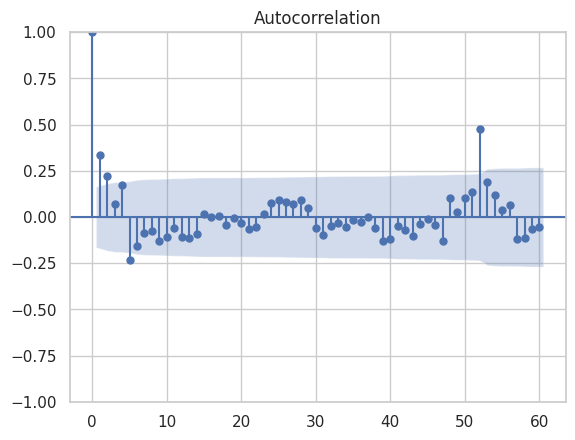

In [18]:
# confirmation of the seasonality every 52 weeks
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(data_weekly['Weekly_Sales'],lags=60)
plt.show()

**SARIMA Forecasting**

---

In [19]:
pip install pmdarima


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 11.8 MB/s eta 0:00:00


In [20]:
from pmdarima import auto_arima

In [25]:
# test days
weeks = 12
# define training and testing df on three months period
train_df = data_weekly[:-weeks]
test_df = data_weekly[-weeks:]

In [22]:
# running the model ARIMA
arima_model = auto_arima(train_df['Weekly_Sales'], seasonal = True, m = 52)
print(arima_model.summary())
# the model identified the seasonality on 52 weeks ar.S.L52 = 0.6587 with p.value < 0.001

                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                  131
Model:             SARIMAX(2, 0, 2)x(1, 0, [], 52)   Log Likelihood               -2184.013
Date:                             Wed, 09 Sep 2026   AIC                           4382.026
Time:                                     06:26:44   BIC                           4402.153
Sample:                                 02-05-2010   HQIC                          4390.205
                                      - 08-03-2012                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   3.109e+07   1.86e-08   1.67e+15      0.000    3.11e+07    3.11e+07
ar.L1         -0.7934      

In [26]:
# assign variable to predictions
predictions = arima_model.predict(n_periods = weeks)

In [27]:
# check the parameters for the precision of the model
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

mae = mean_absolute_error(test_df['Weekly_Sales'], arima_model.predict(n_periods = weeks))
rmse = np.sqrt(mean_squared_error(test_df['Weekly_Sales'], arima_model.predict(n_periods = weeks)))
mape = mean_absolute_percentage_error(test_df['Weekly_Sales'], arima_model.predict(n_periods = weeks))
print('MAE:', mae)
print('RMSE:', rmse)
print('MAPE:', mape)


MAE: 706892.4993908213
RMSE: 872634.4291297268
MAPE: 0.015211664052771044


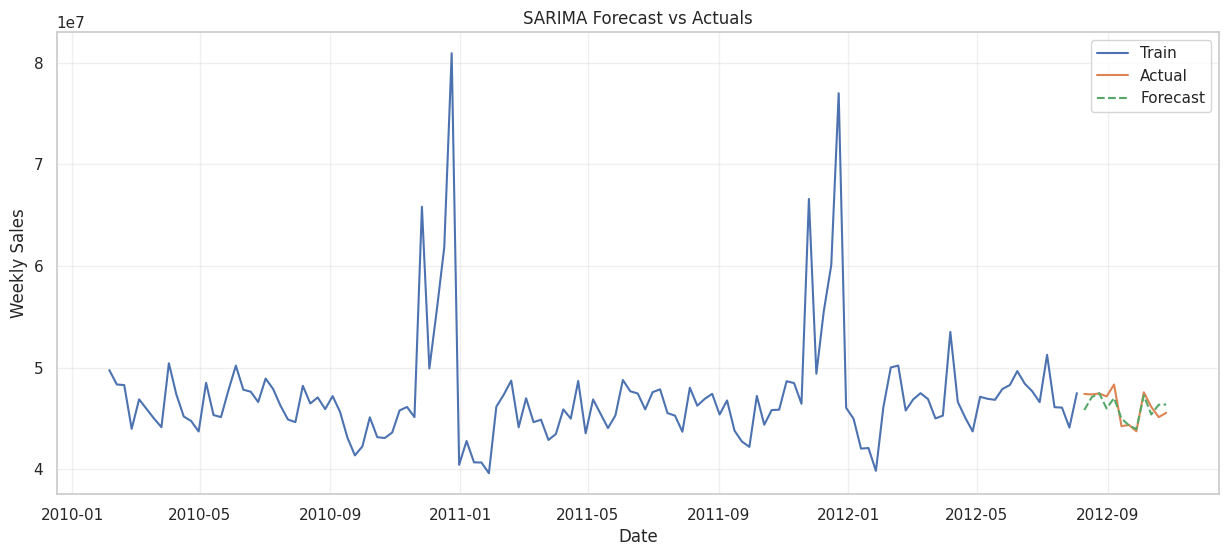

In [28]:
# building the actual vs forecast graph
plt.figure(figsize=(15,6))

plt.plot(
    train_df.index,
    train_df['Weekly_Sales'],
    label='Train'
)

plt.plot(
    test_df.index,
    test_df['Weekly_Sales'],
    label='Actual'
)

plt.plot(
    test_df.index,
    predictions,
    label='Forecast',
    linestyle='--'
)

plt.title('SARIMA Forecast vs Actuals')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.legend()

plt.grid(alpha=0.3)

plt.show()

**SARIAMAX Forecasting**

---

In [29]:
# crete the dataframe for the extrogenous test
X_train = train_df[
    ['AVG_Fuel_Price',
     'AVG_CPI',
     'AVG_Unemployment']
]

X_test = test_df[
    ['AVG_Fuel_Price',
     'AVG_CPI',
     'AVG_Unemployment']
]


In [30]:
# running the SARIMAX model
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarimax_model = SARIMAX(
    train_df['Weekly_Sales'],
    exog=X_train,
    order=(2,0,2),
    seasonal_order=(1,0,0,52),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_results = sarimax_model.fit()

print(sarimax_results.summary())
# AVG_Fuel_Price = -2.45e+06 --> increasing the fuel price the revenue decreases
# AVG_CPI = 3.277e+05 --> positive association with sales although may be reflect inflation over time
# AVG_Unemployment = -9.358e+04 --> higher the unemployment rate lower the revenue

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


                                      SARIMAX Results                                      
Dep. Variable:                        Weekly_Sales   No. Observations:                  131
Model:             SARIMAX(2, 0, 2)x(1, 0, [], 52)   Log Likelihood               -1261.692
Date:                             Wed, 09 Sep 2026   AIC                           2541.383
Time:                                     06:31:06   BIC                           2562.477
Sample:                                 02-05-2010   HQIC                          2549.821
                                      - 08-03-2012                                         
Covariance Type:                               opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
AVG_Fuel_Price    -2.45e+06   6.52e-06  -3.76e+11      0.000   -2.45e+06   -2.45e+06
AVG_CPI  

In [31]:
# assigning variable to predictions
sarimax_predictions = sarimax_results.forecast(
    steps=len(test_df),
    exog=X_test
)

In [32]:
# calculating the parameters
mae = mean_absolute_error(
    test_df['Weekly_Sales'],
    sarimax_predictions
)

rmse = np.sqrt(
    mean_squared_error(
        test_df['Weekly_Sales'],
        sarimax_predictions
    )
)

mape = mean_absolute_percentage_error(
    test_df['Weekly_Sales'],
    sarimax_predictions
)

print(f"MAE: {mae:,.0f}")
print(f"RMSE: {rmse:,.0f}")
print(f"MAPE: {mape:.4f}")
# the MAPE decreases from 1.52% to 1.35% indicating a better model

MAE: 620,225
RMSE: 768,152
MAPE: 0.0135


**SARIMAX Forecasting with holidays**

---

In [33]:
# crete the dataframe for the extrogenous test
X_train = train_df[
    ['AVG_Fuel_Price',
     'AVG_CPI',
     'AVG_Unemployment',
     'Holiday_flag']
]

X_test = test_df[
    ['AVG_Fuel_Price',
     'AVG_CPI',
     'AVG_Unemployment',
     'Holiday_flag']
]

In [34]:
# running the model
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarimax_model = SARIMAX(
    train_df['Weekly_Sales'],
    exog=X_train,
    order=(2,0,2),
    seasonal_order=(1,0,0,52),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_results = sarimax_model.fit()

print(sarimax_results.summary())

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


                                      SARIMAX Results                                      
Dep. Variable:                        Weekly_Sales   No. Observations:                  131
Model:             SARIMAX(2, 0, 2)x(1, 0, [], 52)   Log Likelihood               -1262.763
Date:                             Wed, 09 Sep 2026   AIC                           2545.525
Time:                                     06:31:39   BIC                           2568.964
Sample:                                 02-05-2010   HQIC                          2554.900
                                      - 08-03-2012                                         
Covariance Type:                               opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
AVG_Fuel_Price   -2.126e+06   1818.878  -1169.102      0.000   -2.13e+06   -2.12e+06
AVG_CPI  

In [35]:
# assigning the variable for the predictions
sarimax_predictions = sarimax_results.forecast(
    steps=len(test_df),
    exog=X_test
)

In [36]:
# calculating the parameters to check the model
mae = mean_absolute_error(
    test_df['Weekly_Sales'],
    sarimax_predictions
)

rmse = np.sqrt(
    mean_squared_error(
        test_df['Weekly_Sales'],
        sarimax_predictions
    )
)

mape = mean_absolute_percentage_error(
    test_df['Weekly_Sales'],
    sarimax_predictions
)

print(f"MAE: {mae:,.0f}")
print(f"RMSE: {rmse:,.0f}")
print(f"MAPE: {mape:.4f}")
# adding external economics factors increases the accuracy of the model by 21% (MAPE 1.35% --> MAPE 1.24%)

MAE: 566,507
RMSE: 732,546
MAPE: 0.0124


**Sarima future forecasting for 8 weeks**

---

In [37]:
# 8 weeks prediction using SARIMA model, no extrogenous factors used since they are not known
final_model = auto_arima(
    data_weekly['Weekly_Sales'],
    seasonal=True,
    m=52
)

In [54]:
# prediction for the next two months
future_forecast = final_model.predict(
    n_periods=8
)

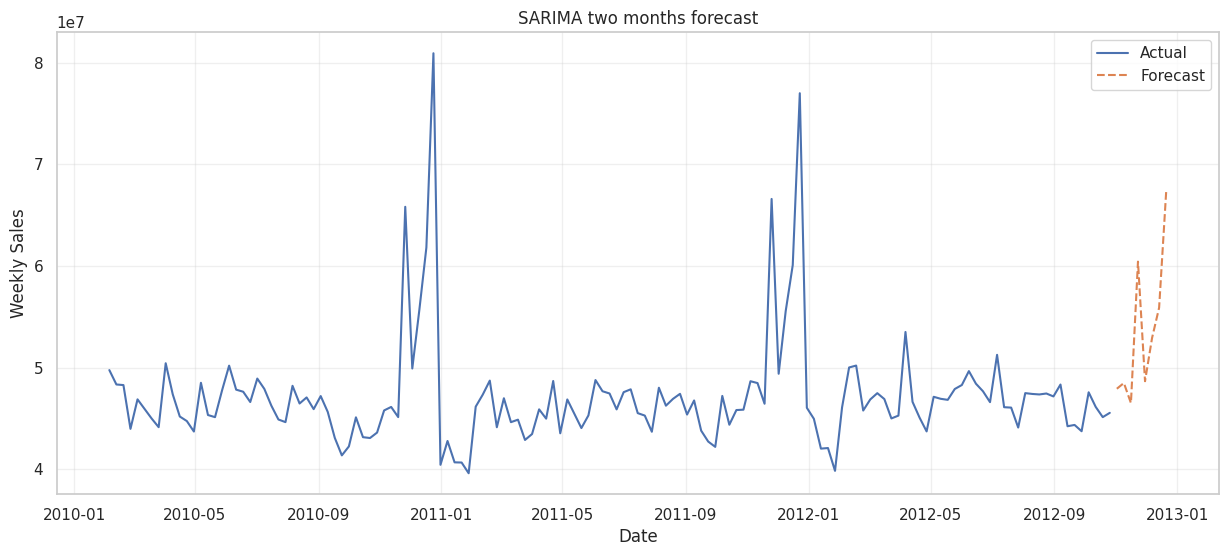

In [56]:
# graph of the historical data and 8 weeks forecast
plt.figure(figsize=(15,6))

plt.plot(
    data_weekly.index,
    data_weekly['Weekly_Sales'],
    label='Actual'
)

plt.plot(
    future_forecast.index,
    future_forecast,
    label='Forecast',
    linestyle='--'
)

plt.title('SARIMA two months forecast')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.legend()

plt.grid(alpha=0.3)

plt.show()
# the model can forecast the increasing of the sales coming for the holidays

In [58]:
# export csv files
data.to_csv('data.csv')
data_weekly.to_csv('data_weekly.csv')
future_forecast.to_csv('future_forecast.csv')